1. Przetwarzanie wstępne i balansowanie zbioru danych
W pierwotnym zbiorze danych zidentyfikowano znaczny brak równowagi klasowej (85% przypadków patologicznych). Aby zapobiec biasowi modelu, zastosowano technikę Sliding Window (przesuwnego okna) o długości 2.0s z różnym krokiem (stride):

Dla klasy Normal: krok 0.5s (z zakładką), co pozwoliło na multiplikację rzadszych próbek.

Dla klasy Pathology: krok 2.0s (brak zakładki).

Efekt: Zwiększono liczebność próbek serca (HS) do 530 oraz płuc (LS) do 485, uzyskując niemal idealny balans klasowy.

In [1]:
import os
import librosa
import soundfile as sf
import pandas as pd


def _ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def _is_normal_label(label) -> bool:
    return str(label).strip().lower() == "normal"


def segment_from_split_csv(
    csv_path: str,
    audio_root: str = "Sound",
    output_root: str = "Sound_segmented",
    win_sec: float = 2.0,
    normal_step_sec: float = 0.5,
) -> None:
    df = pd.read_csv(csv_path)

    required = {"filename", "label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV {csv_path} missing columns: {sorted(missing)}")

    # nazwa splitu: train.csv -> train, csv_files/train.csv -> train
    split_name = os.path.splitext(os.path.basename(csv_path))[0]

    new_segments = []

    print(f"[{split_name}] Przetwarzam {len(df)} plików z {csv_path}...")

    for _, row in df.iterrows():
        rel_path = str(row["filename"]).strip().replace("\\", "/")
        label_text = row["label"]
        source = str(row["source"]).strip() if "source" in df.columns else "UNKNOWN"

        input_path = os.path.join(audio_root, rel_path)

        # Mała pomoc na wypadek MIX vs Mix
        if not os.path.exists(input_path) and rel_path.startswith("MIX/"):
            input_path_alt = os.path.join(audio_root, "Mix", rel_path[len("MIX/"):])
            if os.path.exists(input_path_alt):
                input_path = input_path_alt

        if not os.path.exists(input_path):
            # plik z CSV nie istnieje na dysku -> pomijamy
            continue

        try:
            y, sr = librosa.load(input_path, sr=None)
        except Exception:
            continue

        win_len = int(win_sec * sr)
        if win_len <= 0 or len(y) < win_len:
            continue

        is_normal = _is_normal_label(label_text)
        step = int(normal_step_sec * sr) if is_normal else win_len
        if step <= 0:
            step = win_len

        out_dir = os.path.join(output_root, split_name, f"{source}_segmented")
        _ensure_dir(out_dir)

        stem = os.path.splitext(os.path.basename(rel_path))[0]

        count = 0
        for start in range(0, len(y) - win_len + 1, step):
            segment = y[start : start + win_len]
            seg_name = f"{stem}_seg_{count}.wav"
            out_path = os.path.join(out_dir, seg_name)
            sf.write(out_path, segment, sr)

            # zapisuj ścieżkę względną od output_root (wygodne do późniejszego użycia)
            seg_rel = os.path.join(split_name, f"{source}_segmented", seg_name).replace("\\", "/")
            new_segments.append(
                {
                    "filename": seg_rel,
                    "label": 0 if is_normal else 1,
                    "label_text": "Normal" if is_normal else "Pathology",
                    "source": source,
                    "original_filename": rel_path,
                }
            )
            count += 1

    out_csv = os.path.join(os.path.dirname(csv_path), f"{split_name}_segmented.csv")
    pd.DataFrame(new_segments).to_csv(out_csv, index=False)

    print(f"[{split_name}] Sukces! Stworzono {len(new_segments)} segmentów.")
    if new_segments:
        out_df = pd.DataFrame(new_segments)
        print(out_df["label"].value_counts(normalize=True))
    print("-" * 30)


if __name__ == "__main__":
    for split in ["train", "val", "test"]:
        p = os.path.join("csv_files", f"{split}.csv")
        if os.path.exists(p):
            segment_from_split_csv(p)
        else:
            print(f"Pomijam, brak pliku: {p}")

[train] Przetwarzam 273 plików z csv_files\train.csv...
[train] Sukces! Stworzono 2621 segmentów.
label
1    0.598245
0    0.401755
Name: proportion, dtype: float64
------------------------------
[val] Przetwarzam 39 plików z csv_files\val.csv...
[val] Sukces! Stworzono 372 segmentów.
label
1    0.564516
0    0.435484
Name: proportion, dtype: float64
------------------------------
[test] Przetwarzam 78 plików z csv_files\test.csv...
[test] Sukces! Stworzono 872 segmentów.
label
0    0.526376
1    0.473624
Name: proportion, dtype: float64
------------------------------


2. Klasyfikacja z wykorzystaniem Drzewa Decyzyjnego
Jako model bazowy (baseline) wybrano Drzewo Decyzyjne (Decision Tree) ze względu na jego wysoką interpretowalność. Cechy wejściowe stanowią współczynniki MFCC (Mel-frequency cepstral coefficients), które najlepiej oddają charakterystykę sygnałów medycznych.

Ekstrakcja cech z csv_files/train_segmented.csv (source=HS)...
Ekstrakcja cech z csv_files/test_segmented.csv (source=HS)...

--- WYNIKI (HS) Drzewo Decyzyjne ---
              precision    recall  f1-score   support

      Normal       0.75      0.11      0.19        54
   Pathology       0.45      0.95      0.62        42

    accuracy                           0.48        96
   macro avg       0.60      0.53      0.40        96
weighted avg       0.62      0.48      0.38        96



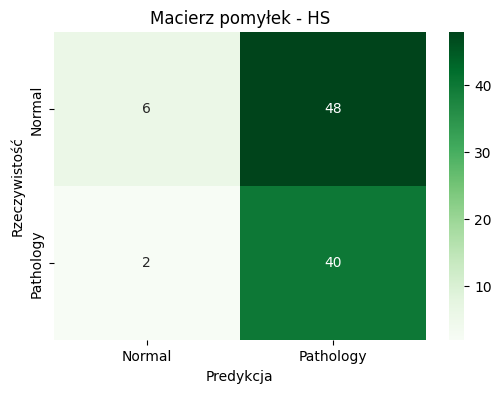

Ekstrakcja cech z csv_files/train_segmented.csv (source=LS)...
Ekstrakcja cech z csv_files/test_segmented.csv (source=LS)...

--- WYNIKI (LS) Drzewo Decyzyjne ---
              precision    recall  f1-score   support

      Normal       0.94      0.70      0.81       135
   Pathology       0.35      0.79      0.49        28

    accuracy                           0.72       163
   macro avg       0.65      0.74      0.65       163
weighted avg       0.84      0.72      0.75       163



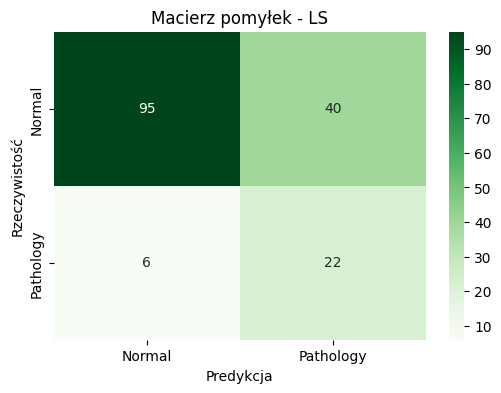

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

AUDIO_ROOT = "Sound_segmented"

def extract_features_from_csv(audio_root, csv_file, source_filter=None):
    df = pd.read_csv(csv_file)

    if source_filter is not None and "source" in df.columns:
        df = df[df["source"] == source_filter]

    features_list = []
    labels = []

    print(f"Ekstrakcja cech z {csv_file} (source={source_filter})...")

    for _, row in df.iterrows():
        # w segmented.csv filename powinien być np. "train/HS_segmented/xxx.wav"
        file_path = os.path.join(audio_root, str(row["filename"]))

        try:
            y, sr = librosa.load(file_path, sr=None)
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
            mfccs_scaled = np.mean(mfccs.T, axis=0)
            features_list.append(mfccs_scaled)
            labels.append(int(row["label"]))
        except:
            continue

    return np.array(features_list), np.array(labels)


def train_and_eval(source_name):
    X_train, y_train = extract_features_from_csv(AUDIO_ROOT, "csv_files/train_segmented.csv", source_filter=source_name)
    X_test, y_test = extract_features_from_csv(AUDIO_ROOT, "csv_files/test_segmented.csv", source_filter=source_name)

    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    print(f"\n--- WYNIKI ({source_name}) Drzewo Decyzyjne ---")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Pathology"]))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["Normal", "Pathology"],
                yticklabels=["Normal", "Pathology"])
    plt.title(f"Macierz pomyłek - {source_name}")
    plt.xlabel("Predykcja")
    plt.ylabel("Rzeczywistość")
    plt.show()
if __name__ == "__main__":
    train_and_eval("HS")
    train_and_eval("LS")